In [1]:
# CELL 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/project churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Confirm it loaded
print("✅ Data loaded successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

✅ Data loaded successfully!
Rows: 7043, Columns: 21


In [2]:
# CELL 2: First peek at the data
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
# CELL 3: Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# CELL 4: Find the problem rows in TotalCharges
# Try to convert TotalCharges to numeric, errors='coerce' will turn bad values into NaN
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count how many became NaN (these are the problem rows)
print(f"Problematic rows: {df['TotalCharges_numeric'].isna().sum()}")

# Look at those problem rows
problem_rows = df[df['TotalCharges_numeric'].isna()]
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

Problematic rows: 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [5]:
# CELL 5: Clean the data

# Step 1: Convert TotalCharges to numeric properly
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 2: Fill missing values with 0 (new customers with no billing history)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Step 3: Drop the temporary helper column we created
df = df.drop(columns=['TotalCharges_numeric'])

# Step 4: Convert SeniorCitizen from 0/1 to No/Yes for consistency
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Step 5: Strip any extra spaces in text columns
text_cols = df.select_dtypes(include='object').columns
for col in text_cols:
    df[col] = df[col].str.strip()

# Verify the fix
print("✅ Data cleaning complete!")
print(f"\nTotalCharges data type: {df['TotalCharges'].dtype}")
print(f"Missing values in TotalCharges: {df['TotalCharges'].isna().sum()}")
print(f"\nDataset shape: {df.shape}")

✅ Data cleaning complete!

TotalCharges data type: float64
Missing values in TotalCharges: 0

Dataset shape: (7043, 21)


In [6]:
# CELL 6: Final data quality check
print("=" * 50)
print("FINAL DATA QUALITY REPORT")
print("=" * 50)

print(f"\n📊 Total Rows: {df.shape[0]}")
print(f"📊 Total Columns: {df.shape[1]}")
print(f"📊 Missing Values: {df.isna().sum().sum()}")
print(f"📊 Duplicate Rows: {df.duplicated().sum()}")

print(f"\n🎯 Churn Rate: {(df['Churn']=='Yes').mean()*100:.2f}%")
print(f"🎯 Churned Customers: {(df['Churn']=='Yes').sum()}")
print(f"🎯 Retained Customers: {(df['Churn']=='No').sum()}")

FINAL DATA QUALITY REPORT

📊 Total Rows: 7043
📊 Total Columns: 21
📊 Missing Values: 0
📊 Duplicate Rows: 0

🎯 Churn Rate: 26.54%
🎯 Churned Customers: 1869
🎯 Retained Customers: 5174


In [7]:
# CELL 7: Save the cleaned data
df.to_csv('telco_churn_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'telco_churn_cleaned.csv'")
print("📂 You can now use this file for Power BI dashboard on Day 2!")

✅ Cleaned dataset saved as 'telco_churn_cleaned.csv'
📂 You can now use this file for Power BI dashboard on Day 2!


In [8]:
# CELL 8: Set up nicer plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Visualization style configured")

✅ Visualization style configured


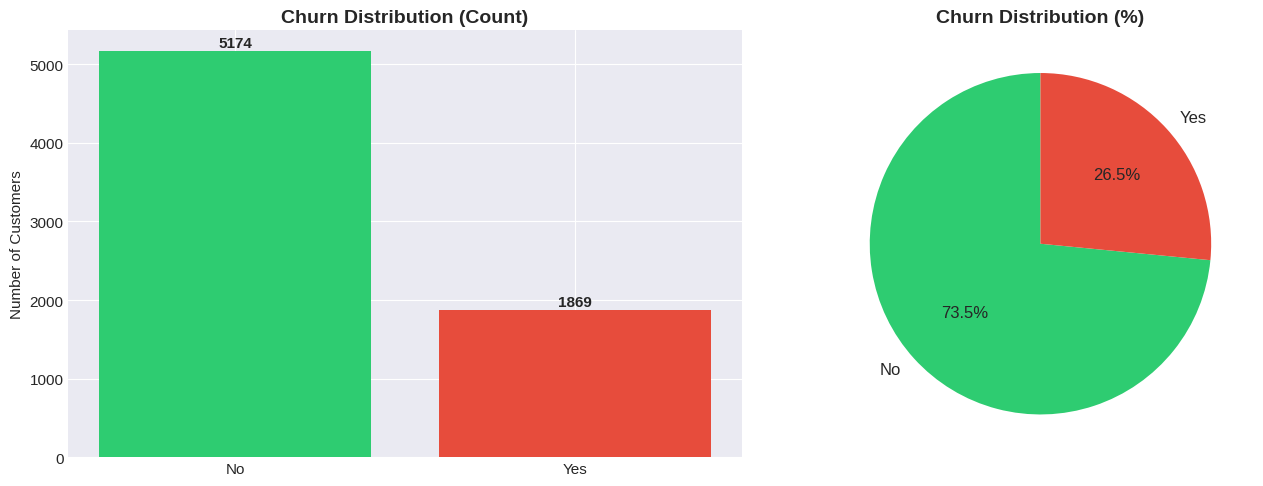


📊 INSIGHT 1: 26.5% of customers have churned.
This is HIGH — industry average for telecom is 15-25%. Action needed!


In [9]:
# CELL 9: Investigation 1 - Overall Churn Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 INSIGHT 1: {(df['Churn']=='Yes').mean()*100:.1f}% of customers have churned.")
print("This is HIGH — industry average for telecom is 15-25%. Action needed!")

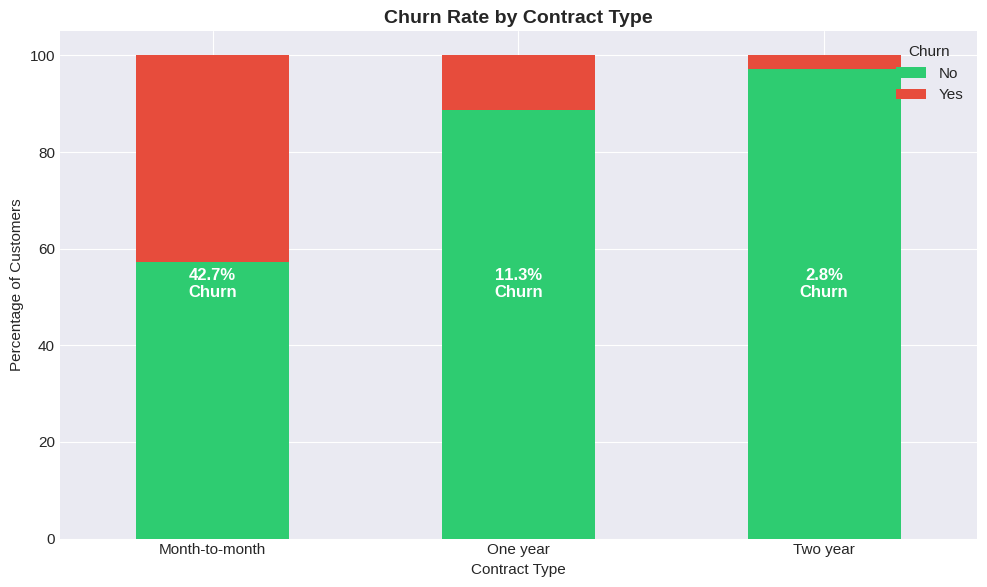


📊 INSIGHT 2 - Churn Rate by Contract:
Churn            Yes
Contract            
Month-to-month  42.7
One year        11.3
Two year         2.8


In [10]:
# CELL 10: Investigation 2 - Churn by Contract Type

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
contract_churn.plot(kind='bar', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Percentage of Customers')
ax.legend(title='Churn', loc='upper right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add percentage labels
for i, contract in enumerate(contract_churn.index):
    churn_pct = contract_churn.loc[contract, 'Yes']
    ax.text(i, 50, f'{churn_pct:.1f}%\nChurn', ha='center', fontweight='bold',
            color='white', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 2 - Churn Rate by Contract:")
print(contract_churn[['Yes']].round(1))

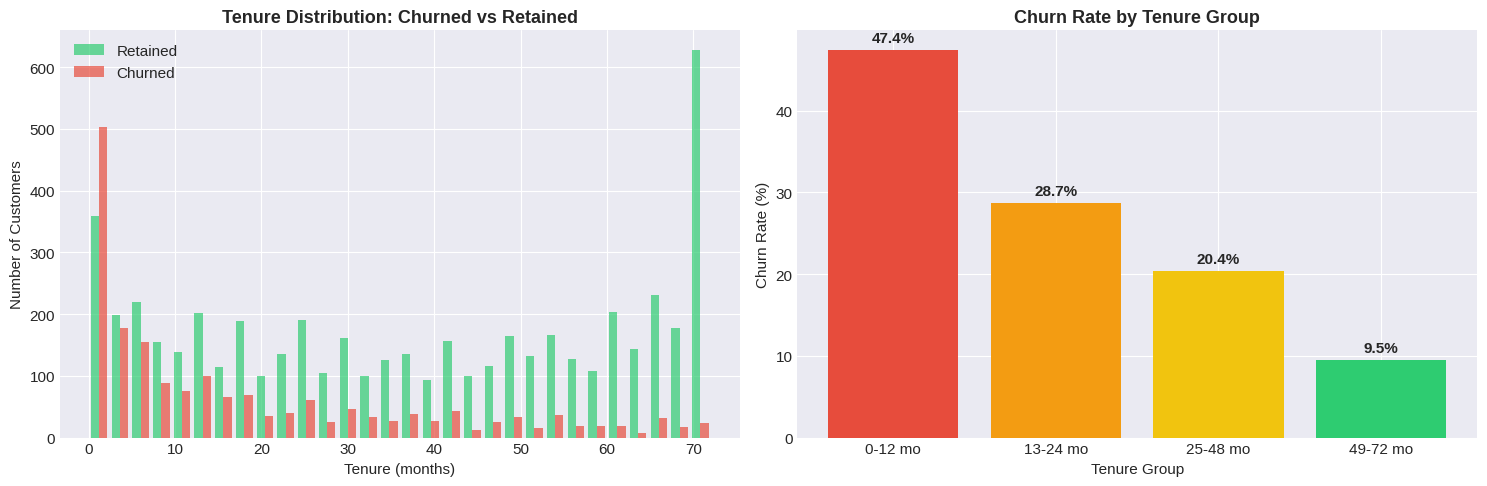


📊 INSIGHT 3 - Churn Rate by Tenure Group:
tenure_group
0-12 mo     47.4
13-24 mo    28.7
25-48 mo    20.4
49-72 mo     9.5
Name: Churn, dtype: float64


In [11]:
# CELL 11: Investigation 3 - Churn by Tenure

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of tenure split by churn
churned = df[df['Churn']=='Yes']['tenure']
retained = df[df['Churn']=='No']['tenure']

axes[0].hist([retained, churned], bins=30, label=['Retained', 'Churned'],
             color=['#2ecc71', '#e74c3c'], stacked=False, alpha=0.7)
axes[0].set_title('Tenure Distribution: Churned vs Retained', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Create tenure buckets
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0-12 mo', '13-24 mo', '25-48 mo', '49-72 mo'],
                             include_lowest=True)

tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean()*100)

axes[1].bar(tenure_churn.index.astype(str), tenure_churn.values,
            color=['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71'])
axes[1].set_title('Churn Rate by Tenure Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Tenure Group')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 3 - Churn Rate by Tenure Group:")
print(tenure_churn.round(1))

/tmp/ipykernel_3255/2210081094.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0],


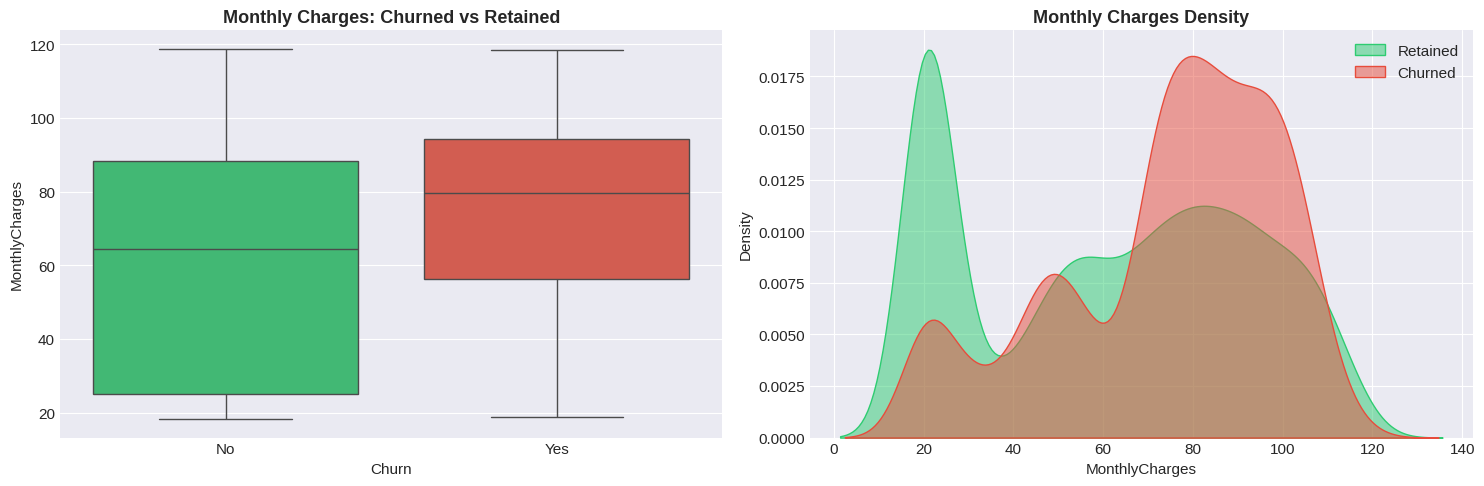


📊 INSIGHT 4 - Avg Monthly Charges:
  Churned customers: $74.44
  Retained customers: $61.27


In [12]:
# CELL 12: Investigation 4 - Monthly Charges vs Churn

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0],
            palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Monthly Charges: Churned vs Retained', fontsize=13, fontweight='bold')

# KDE plot (density curve)
sns.kdeplot(data=df[df['Churn']=='No'], x='MonthlyCharges',
            label='Retained', color='#2ecc71', fill=True, alpha=0.5, ax=axes[1])
sns.kdeplot(data=df[df['Churn']=='Yes'], x='MonthlyCharges',
            label='Churned', color='#e74c3c', fill=True, alpha=0.5, ax=axes[1])
axes[1].set_title('Monthly Charges Density', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n📊 INSIGHT 4 - Avg Monthly Charges:")
print(f"  Churned customers: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"  Retained customers: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

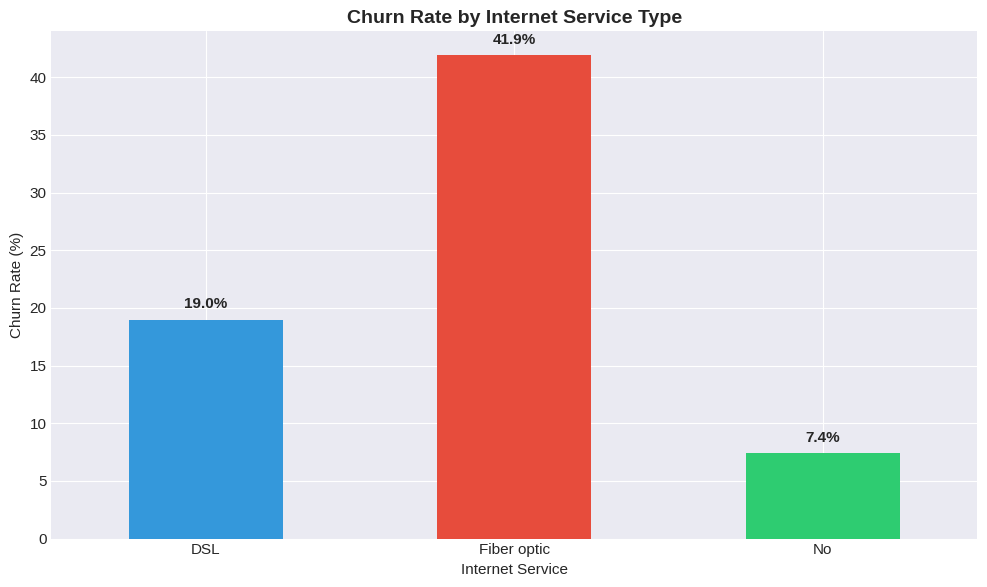


📊 INSIGHT 5 - Churn by Internet Type:
Churn             Yes
InternetService      
DSL              19.0
Fiber optic      41.9
No                7.4


In [13]:
# CELL 13: Investigation 5 - Internet Service vs Churn

internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 6))
internet_churn['Yes'].plot(kind='bar', color=['#3498db', '#e74c3c', '#2ecc71'], ax=ax)
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Churn Rate (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(internet_churn['Yes'].values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 5 - Churn by Internet Type:")
print(internet_churn[['Yes']].round(1))

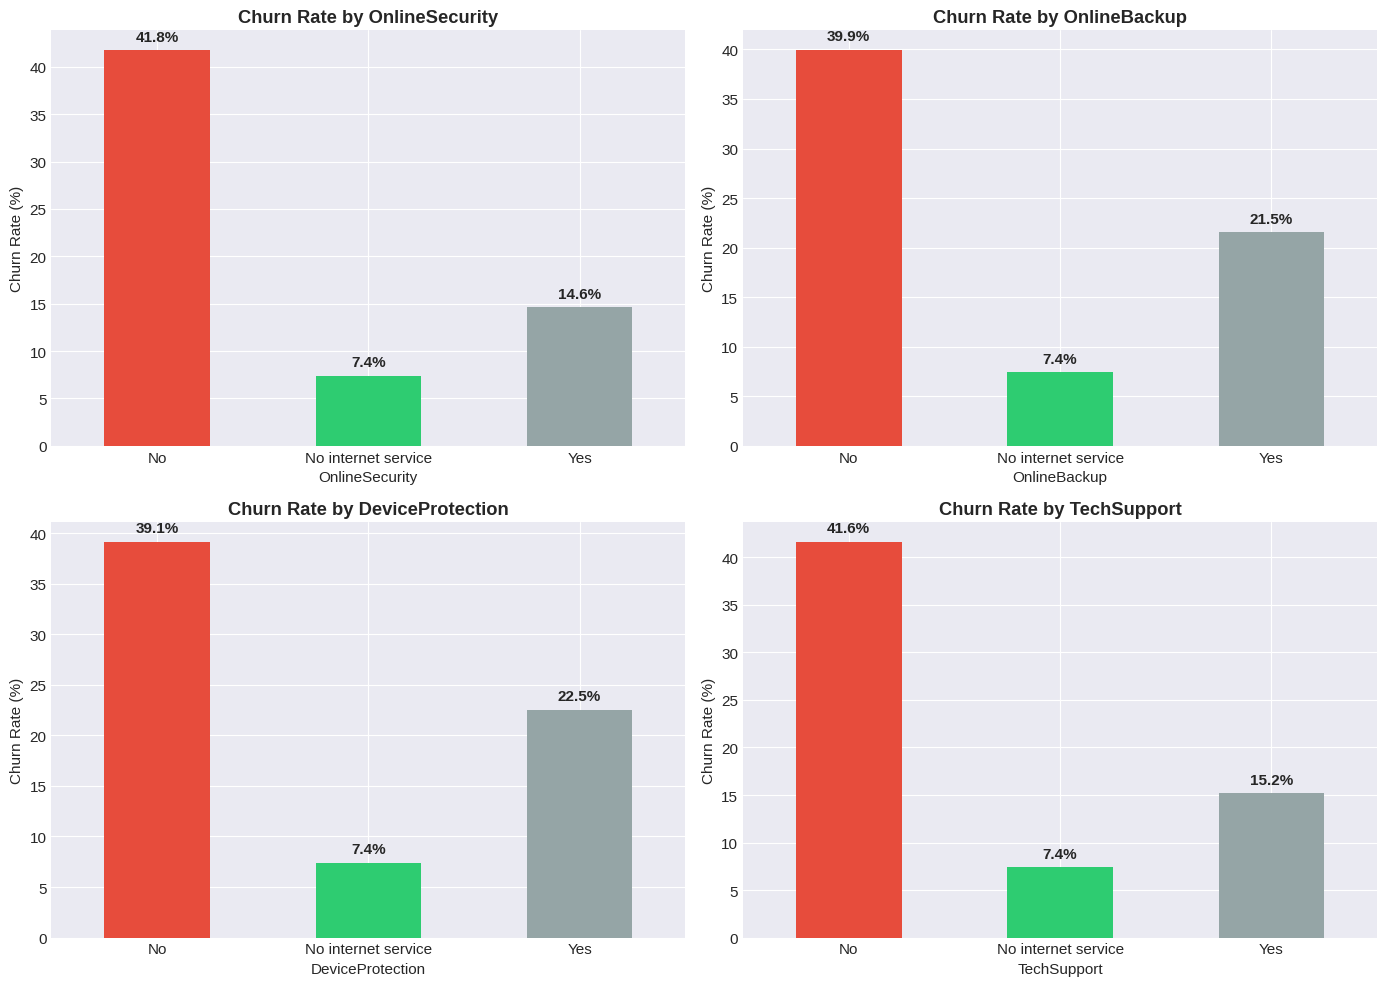


📊 INSIGHT 6: Customers WITHOUT support services churn 3-4x MORE!


In [14]:
# CELL 14: Investigation 6 - Support Services Impact

support_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, service in enumerate(support_services):
    service_churn = pd.crosstab(df[service], df['Churn'], normalize='index') * 100
    service_churn['Yes'].plot(kind='bar', ax=axes[i],
                               color=['#e74c3c', '#2ecc71', '#95a5a6'])
    axes[i].set_title(f'Churn Rate by {service}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    for j, v in enumerate(service_churn['Yes'].values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 6: Customers WITHOUT support services churn 3-4x MORE!")

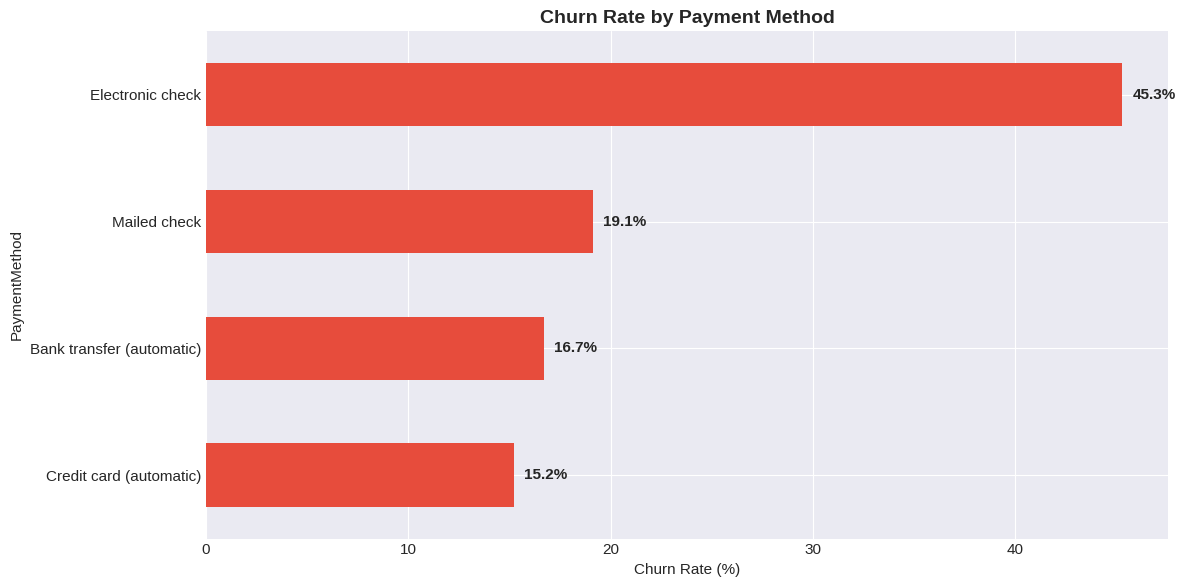


📊 INSIGHT 7 - Churn by Payment Method:
Churn                       Yes
PaymentMethod                  
Electronic check           45.3
Mailed check               19.1
Bank transfer (automatic)  16.7
Credit card (automatic)    15.2


In [15]:
# CELL 15: Investigation 7 - Payment Method vs Churn

payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for i, v in enumerate(payment_churn['Yes'].sort_values().values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 7 - Churn by Payment Method:")
print(payment_churn[['Yes']].round(1).sort_values('Yes', ascending=False))

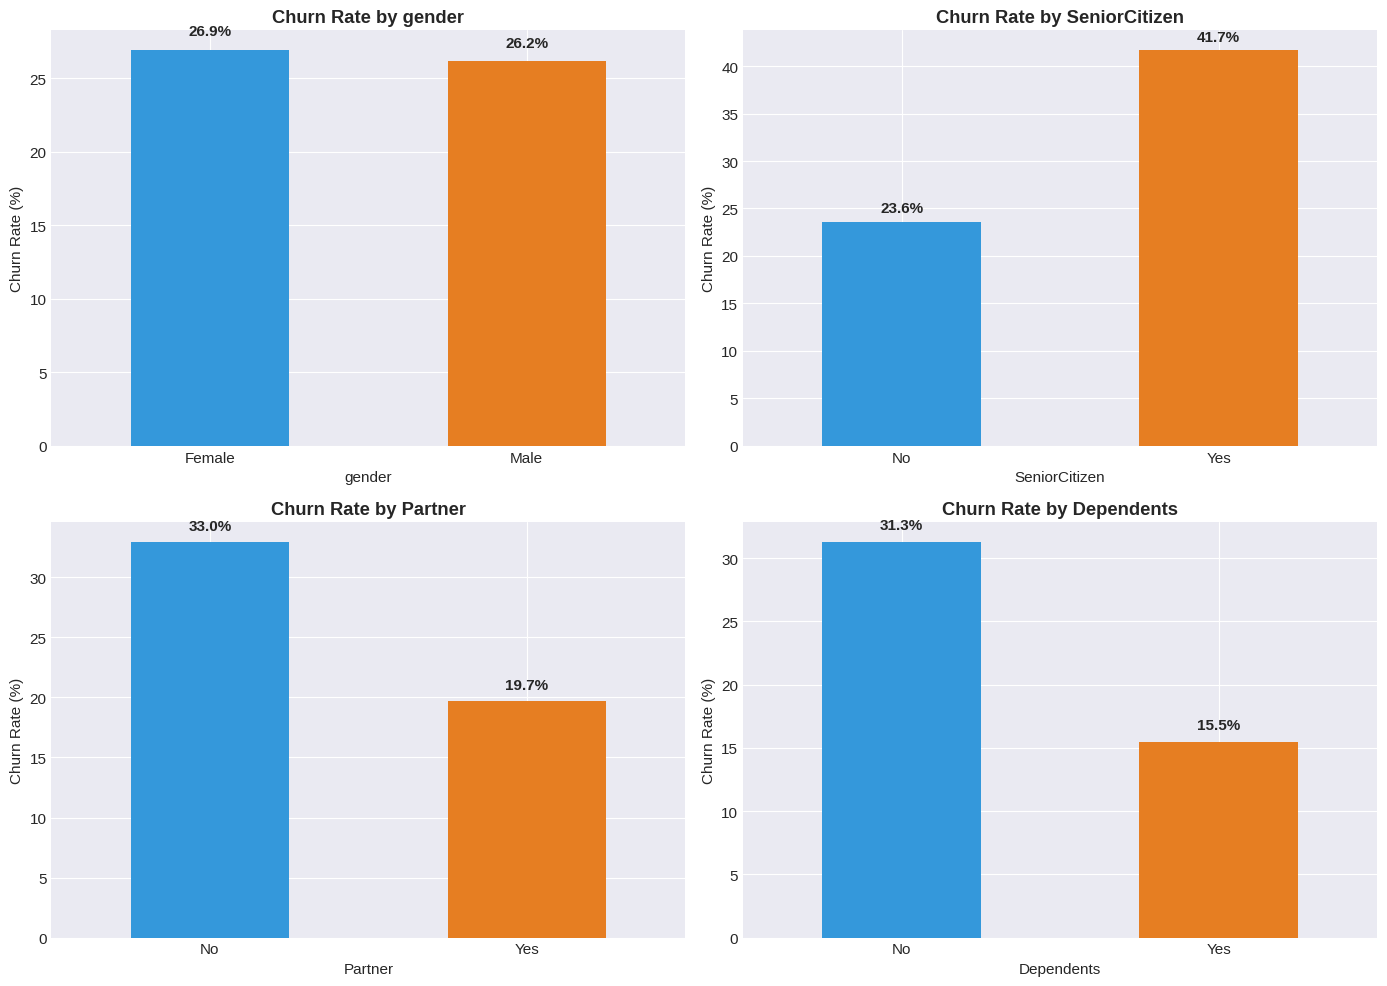


📊 INSIGHT 8 - Demographics:
- Gender: NO impact (both ~26%)
- SeniorCitizen: HIGH impact (~42% vs ~24%)
- Partner: Singles churn more (~33% vs ~20%)
- Dependents: No-dependents churn more (~31% vs ~16%)


In [16]:
# CELL 16: Investigation 8 - Demographics vs Churn

demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, demo in enumerate(demographics):
    demo_churn = pd.crosstab(df[demo], df['Churn'], normalize='index') * 100
    demo_churn['Yes'].plot(kind='bar', ax=axes[i], color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Churn Rate by {demo}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    for j, v in enumerate(demo_churn['Yes'].values):
        axes[i].text(j, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT 8 - Demographics:")
print("- Gender: NO impact (both ~26%)")
print("- SeniorCitizen: HIGH impact (~42% vs ~24%)")
print("- Partner: Singles churn more (~33% vs ~20%)")
print("- Dependents: No-dependents churn more (~31% vs ~16%)")

In [17]:
# CELL 17: Rule-Based Customer Segmentation

def segment_customer(row):
    if row['tenure'] > 24 and row['MonthlyCharges'] > 70:
        return '🏆 VIP / High-Value Loyal'
    elif row['tenure'] > 24 and row['MonthlyCharges'] <= 70:
        return '💎 Loyal Low-Spender'
    elif row['tenure'] <= 24 and row['MonthlyCharges'] > 70:
        return '🚨 At-Risk Premium'
    else:
        return '🌱 New / Standard'

df['Segment'] = df.apply(segment_customer, axis=1)

# Show distribution
segment_counts = df['Segment'].value_counts()
print("📊 Customer Segment Distribution:")
print(segment_counts)
print(f"\nTotal customers: {segment_counts.sum()}")

📊 Customer Segment Distribution:
Segment
🏆 VIP / High-Value Loyal    2230
🌱 New / Standard            1857
💎 Loyal Low-Spender         1603
🚨 At-Risk Premium           1353
Name: count, dtype: int64

Total customers: 7043


/tmp/ipykernel_3255/144961324.py:32: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/144961324.py:32: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/144961324.py:32: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/144961324.py:32: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/co

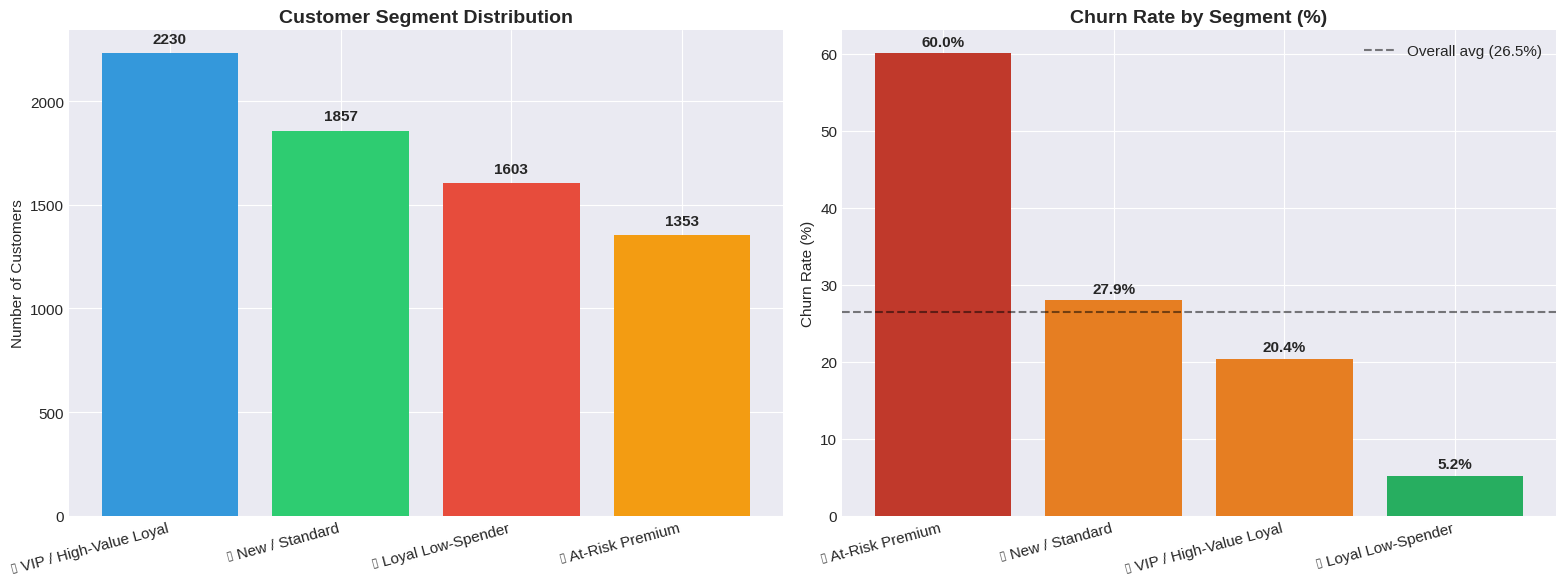


📊 INSIGHT - Segment Churn Rates:
Segment
🚨 At-Risk Premium           60.0
🌱 New / Standard            27.9
🏆 VIP / High-Value Loyal    20.4
💎 Loyal Low-Spender          5.2
Name: Churn, dtype: float64


In [18]:
# CELL 18: Visualize Segments and Their Churn Rates

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Segment Distribution
segment_counts = df['Segment'].value_counts()
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
axes[0].bar(range(len(segment_counts)), segment_counts.values, color=colors)
axes[0].set_xticks(range(len(segment_counts)))
axes[0].set_xticklabels(segment_counts.index, rotation=15, ha='right')
axes[0].set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Chart 2: Churn Rate per Segment
segment_churn = df.groupby('Segment')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)

bars = axes[1].bar(range(len(segment_churn)), segment_churn.values,
                    color=['#c0392b' if v > 30 else '#e67e22' if v > 20 else '#27ae60'
                           for v in segment_churn.values])
axes[1].set_xticks(range(len(segment_churn)))
axes[1].set_xticklabels(segment_churn.index, rotation=15, ha='right')
axes[1].set_title('Churn Rate by Segment (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].axhline(y=26.5, color='black', linestyle='--', alpha=0.5, label='Overall avg (26.5%)')
axes[1].legend()
for i, v in enumerate(segment_churn.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT - Segment Churn Rates:")
print(segment_churn.round(1))

In [19]:
# CELL 19: Revenue Impact Analysis per Segment

segment_analysis = df.groupby('Segment').agg(
    customer_count=('customerID', 'count'),
    avg_monthly_charge=('MonthlyCharges', 'mean'),
    avg_tenure=('tenure', 'mean'),
    churn_rate=('Churn', lambda x: (x=='Yes').mean()*100),
    total_revenue_monthly=('MonthlyCharges', 'sum')
).round(2)

# Calculate annual revenue at risk
segment_analysis['annual_revenue_at_risk'] = (
    segment_analysis['churn_rate'] / 100 *
    segment_analysis['total_revenue_monthly'] * 12
).round(0)

print("📊 SEGMENT ANALYSIS — BUSINESS IMPACT VIEW")
print("=" * 80)
print(segment_analysis)
print("=" * 80)
print(f"\n💰 TOTAL ANNUAL REVENUE AT RISK: ${segment_analysis['annual_revenue_at_risk'].sum():,.0f}")

📊 SEGMENT ANALYSIS — BUSINESS IMPACT VIEW
                          customer_count  avg_monthly_charge  avg_tenure  \
Segment                                                                    
🌱 New / Standard                    1857               38.23        8.59   
🏆 VIP / High-Value Loyal            2230               93.65       53.23   
💎 Loyal Low-Spender                 1603               38.57       50.00   
🚨 At-Risk Premium                   1353               84.60        9.75   

                          churn_rate  total_revenue_monthly  \
Segment                                                       
🌱 New / Standard               27.95                70991.7   
🏆 VIP / High-Value Loyal       20.40               208834.4   
💎 Loyal Low-Spender             5.18                61822.6   
🚨 At-Risk Premium              60.01               114467.9   

                          annual_revenue_at_risk  
Segment                                           
🌱 New / Standard    

In [20]:
# CELL 20: RFM-Style Segmentation

# Recency proxy: Lower tenure = MORE at risk (recent acquisition)
# We'll inverse it: higher score = better
df['R_score'] = pd.qcut(df['tenure'], q=4, labels=[1, 2, 3, 4]).astype(int)

# Frequency: count of services subscribed
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['service_count'] = (df[service_cols] == 'Yes').sum(axis=1)
df['F_score'] = pd.qcut(df['service_count'], q=4, labels=[1, 2, 3, 4],
                         duplicates='drop').astype(int)

# Monetary: TotalCharges
df['M_score'] = pd.qcut(df['TotalCharges'], q=4, labels=[1, 2, 3, 4]).astype(int)

# Combined RFM Score
df['RFM_Score'] = df['R_score'] + df['F_score'] + df['M_score']

# RFM-based segments
def rfm_segment(score):
    if score >= 10:
        return '⭐ Champions'
    elif score >= 8:
        return '💚 Loyal Customers'
    elif score >= 6:
        return '🟡 Potential Loyalists'
    elif score >= 4:
        return '🟠 At-Risk'
    else:
        return '🔴 Lost / Hibernating'

df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)

# Show RFM segment distribution and churn
rfm_summary = df.groupby('RFM_Segment').agg(
    count=('customerID', 'count'),
    avg_RFM_score=('RFM_Score', 'mean'),
    churn_rate=('Churn', lambda x: (x=='Yes').mean()*100)
).round(2).sort_values('avg_RFM_score', ascending=False)

print("📊 RFM SEGMENT ANALYSIS:")
print(rfm_summary)

📊 RFM SEGMENT ANALYSIS:
                       count  avg_RFM_score  churn_rate
RFM_Segment                                            
⭐ Champions             1907          11.23       13.27
💚 Loyal Customers       1310           8.41       22.21
🟡 Potential Loyalists   1552           6.40       25.71
🟠 At-Risk               1368           4.40       39.62
🔴 Lost / Hibernating     906           3.00       42.38


/tmp/ipykernel_3255/1115790067.py:22: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/1115790067.py:22: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/1115790067.py:22: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/1115790067.py:22: UserWarning: Glyph 128154 (\N{GREEN HEART}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_3255/1115790067.py:22: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:1

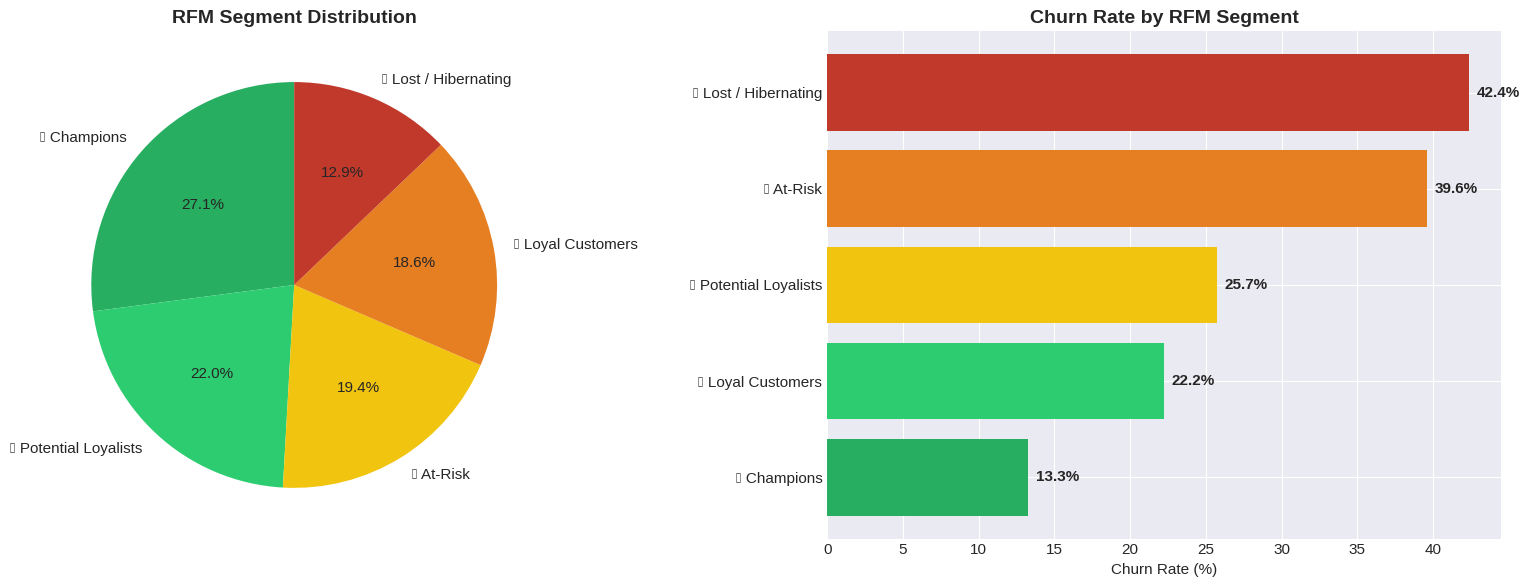

In [21]:
# CELL 21: RFM Segment Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rfm_counts = df['RFM_Segment'].value_counts()
colors_rfm = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#c0392b']

axes[0].pie(rfm_counts.values, labels=rfm_counts.index, autopct='%1.1f%%',
            colors=colors_rfm, startangle=90)
axes[0].set_title('RFM Segment Distribution', fontsize=14, fontweight='bold')

rfm_churn = df.groupby('RFM_Segment')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).sort_values()

axes[1].barh(rfm_churn.index, rfm_churn.values,
              color=['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#c0392b'])
axes[1].set_title('Churn Rate by RFM Segment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for i, v in enumerate(rfm_churn.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [22]:
# CELL 22: Save the segmented dataset for Power BI

# Drop helper columns we don't need in the dashboard
columns_to_keep = [col for col in df.columns if col not in
                   ['R_score', 'F_score', 'M_score', 'tenure_group']]
df_final = df[columns_to_keep]

df_final.to_csv('telco_churn_segmented.csv', index=False)
print("✅ Segmented dataset saved as 'telco_churn_segmented.csv'")
print(f"📂 Columns: {len(df_final.columns)}, Rows: {len(df_final)}")
print(f"📂 New columns added: Segment, service_count, RFM_Score, RFM_Segment")


✅ Segmented dataset saved as 'telco_churn_segmented.csv'
📂 Columns: 25, Rows: 7043
📂 New columns added: Segment, service_count, RFM_Score, RFM_Segment


# **Build the KPI Dashboard in Python**

In [23]:
# CELL 23: Build Business KPIs

print("=" * 70)
print("📊 TELCO CUSTOMER RETENTION — KEY PERFORMANCE INDICATORS")
print("=" * 70)

# ========== KPI 1: Total Customers ==========
total_customers = len(df)
print(f"\n1️⃣ TOTAL CUSTOMERS: {total_customers:,}")

# ========== KPI 2: Churn Rate ==========
churn_rate = (df['Churn']=='Yes').mean() * 100
print(f"2️⃣ CHURN RATE: {churn_rate:.2f}%")
print(f"   → Industry benchmark: 15-25% | Status: {'🚨 ABOVE benchmark' if churn_rate > 25 else '✅ Within benchmark'}")

# ========== KPI 3: Retention Rate ==========
retention_rate = 100 - churn_rate
print(f"3️⃣ RETENTION RATE: {retention_rate:.2f}%")

# ========== KPI 4: Total Monthly Revenue ==========
total_monthly_revenue = df['MonthlyCharges'].sum()
print(f"4️⃣ TOTAL MONTHLY REVENUE: ${total_monthly_revenue:,.2f}")

# ========== KPI 5: Annual Revenue at Risk ==========
churned_customers = df[df['Churn']=='Yes']
revenue_at_risk_annual = churned_customers['MonthlyCharges'].sum() * 12
print(f"5️⃣ ANNUAL REVENUE AT RISK: ${revenue_at_risk_annual:,.2f}")
print(f"   → Approximately ${revenue_at_risk_annual/1_000_000:.2f}M lost per year if churn continues")

# ========== KPI 6: Average Customer Tenure ==========
avg_tenure = df['tenure'].mean()
print(f"6️⃣ AVG CUSTOMER TENURE: {avg_tenure:.1f} months ({avg_tenure/12:.1f} years)")

# ========== KPI 7: Average Revenue Per User (ARPU) ==========
arpu = df['MonthlyCharges'].mean()
print(f"7️⃣ ARPU (Avg Revenue Per User): ${arpu:.2f}/month")

# ========== KPI 8: Customer Lifetime Value (CLV) ==========
# CLV = Avg Monthly Revenue × Avg Tenure
clv = arpu * avg_tenure
print(f"8️⃣ CUSTOMER LIFETIME VALUE (CLV): ${clv:,.2f}")
print(f"   → Each customer is worth ~${clv:,.0f} on average over their lifetime")

# ========== KPI 9: Customer Acquisition Cost (CAC) — Industry Estimate ==========
# Telecom industry avg CAC = ~$300 per customer
cac = 300  # industry benchmark
print(f"9️⃣ CUSTOMER ACQUISITION COST (CAC) — industry benchmark: ${cac}")

# ========== KPI 10: CLV-to-CAC Ratio ==========
clv_cac_ratio = clv / cac
print(f"🔟 CLV : CAC RATIO: {clv_cac_ratio:.2f}")
print(f"   → Healthy ratio is >3:1 | Status: {'✅ Healthy' if clv_cac_ratio > 3 else '🚨 Unhealthy'}")

print("\n" + "=" * 70)

📊 TELCO CUSTOMER RETENTION — KEY PERFORMANCE INDICATORS

1️⃣ TOTAL CUSTOMERS: 7,043
2️⃣ CHURN RATE: 26.54%
   → Industry benchmark: 15-25% | Status: 🚨 ABOVE benchmark
3️⃣ RETENTION RATE: 73.46%
4️⃣ TOTAL MONTHLY REVENUE: $456,116.60
5️⃣ ANNUAL REVENUE AT RISK: $1,669,570.20
   → Approximately $1.67M lost per year if churn continues
6️⃣ AVG CUSTOMER TENURE: 32.4 months (2.7 years)
7️⃣ ARPU (Avg Revenue Per User): $64.76/month
8️⃣ CUSTOMER LIFETIME VALUE (CLV): $2,096.41
   → Each customer is worth ~$2,096 on average over their lifetime
9️⃣ CUSTOMER ACQUISITION COST (CAC) — industry benchmark: $300
🔟 CLV : CAC RATIO: 6.99
   → Healthy ratio is >3:1 | Status: ✅ Healthy



In [24]:
# CELL 24: Save KPIs as a structured table

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Customers',
        'Churn Rate (%)',
        'Retention Rate (%)',
        'Total Monthly Revenue ($)',
        'Annual Revenue at Risk ($)',
        'Avg Tenure (months)',
        'ARPU ($)',
        'CLV ($)',
        'CAC ($)',
        'CLV:CAC Ratio'
    ],
    'Value': [
        total_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(total_monthly_revenue, 2),
        round(revenue_at_risk_annual, 2),
        round(avg_tenure, 1),
        round(arpu, 2),
        round(clv, 2),
        cac,
        round(clv_cac_ratio, 2)
    ],
    'Benchmark / Target': [
        'N/A',
        '15-25% (Industry)',
        '> 85%',
        'N/A',
        '< $500K',
        '> 36 months',
        '> $70',
        '> $2,500',
        '< $250',
        '> 3.0'
    ],
    'Status': [
        'ℹ️',
        '🚨 Above benchmark',
        '🟡 Below target',
        '✅',
        '🚨 High',
        '🟡 Just below target',
        '🟡 Just below target',
        '🟡 Below target',
        '🚨 Above target',
        '✅ Healthy'
    ]
})

print("📋 KPI SUMMARY DASHBOARD")
print("=" * 80)
print(kpi_summary.to_string(index=False))

# Save for Power BI
kpi_summary.to_csv('kpi_summary.csv', index=False)
print("\n✅ KPI summary saved as 'kpi_summary.csv'")

📋 KPI SUMMARY DASHBOARD
                       KPI      Value Benchmark / Target              Status
           Total Customers    7043.00                N/A                  ℹ️
            Churn Rate (%)      26.54  15-25% (Industry)   🚨 Above benchmark
        Retention Rate (%)      73.46              > 85%      🟡 Below target
 Total Monthly Revenue ($)  456116.60                N/A                   ✅
Annual Revenue at Risk ($) 1669570.20            < $500K              🚨 High
       Avg Tenure (months)      32.40        > 36 months 🟡 Just below target
                  ARPU ($)      64.76              > $70 🟡 Just below target
                   CLV ($)    2096.41           > $2,500      🟡 Below target
                   CAC ($)     300.00             < $250      🚨 Above target
             CLV:CAC Ratio       6.99              > 3.0           ✅ Healthy

✅ KPI summary saved as 'kpi_summary.csv'


In [25]:
# CELL 25: Segment-Level KPIs

segment_kpis = df.groupby('Segment').agg(
    Customer_Count=('customerID', 'count'),
    Churn_Rate_Pct=('Churn', lambda x: (x=='Yes').mean()*100),
    Avg_Tenure_Months=('tenure', 'mean'),
    ARPU=('MonthlyCharges', 'mean'),
    Total_Monthly_Revenue=('MonthlyCharges', 'sum')
).round(2)

# Calculate CLV per segment
segment_kpis['CLV_per_Customer'] = (
    segment_kpis['ARPU'] * segment_kpis['Avg_Tenure_Months']
).round(0)

# Calculate annual revenue at risk per segment
segment_kpis['Annual_Revenue_at_Risk'] = (
    segment_kpis['Churn_Rate_Pct']/100 *
    segment_kpis['Total_Monthly_Revenue'] * 12
).round(0)

# Calculate % of total revenue at risk
total_risk = segment_kpis['Annual_Revenue_at_Risk'].sum()
segment_kpis['Pct_of_Total_Risk'] = (
    segment_kpis['Annual_Revenue_at_Risk'] / total_risk * 100
).round(1)

print("📊 SEGMENT-LEVEL KPI SCORECARD")
print("=" * 100)
print(segment_kpis)
print("=" * 100)

# Save for later
segment_kpis.to_csv('segment_kpis.csv')
print("\n✅ Segment KPIs saved as 'segment_kpis.csv'")

📊 SEGMENT-LEVEL KPI SCORECARD
                          Customer_Count  Churn_Rate_Pct  Avg_Tenure_Months  \
Segment                                                                       
🌱 New / Standard                    1857           27.95               8.59   
🏆 VIP / High-Value Loyal            2230           20.40              53.23   
💎 Loyal Low-Spender                 1603            5.18              50.00   
🚨 At-Risk Premium                   1353           60.01               9.75   

                           ARPU  Total_Monthly_Revenue  CLV_per_Customer  \
Segment                                                                    
🌱 New / Standard          38.23                70991.7             328.0   
🏆 VIP / High-Value Loyal  93.65               208834.4            4985.0   
💎 Loyal Low-Spender       38.57                61822.6            1928.0   
🚨 At-Risk Premium         84.60               114467.9             825.0   

                          Annual_Reven

# **Machine Learning Churn Prediction Model**

# **Raw Data → Clean → Encode → Split → Train → Predict → Evaluate → Interpret**

In [26]:
# CELL 26: Prepare Data for Machine Learning

# Step 1: Create a copy so we don't break our original df
df_ml = df.copy()

# Step 2: Drop columns we don't need for ML
columns_to_drop = ['customerID', 'Segment', 'RFM_Segment', 'service_count', 'RFM_Score']
df_ml = df_ml.drop(columns=[col for col in columns_to_drop if col in df_ml.columns])

# Step 3: Convert target variable Churn (Yes/No) to (1/0)
df_ml['Churn'] = df_ml['Churn'].map({'Yes': 1, 'No': 0})

# Step 4: Convert ALL other categorical columns to numbers using one-hot encoding
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Step 5: Confirm everything is numeric now
print("✅ Data prepared for ML!")
print(f"📊 Shape: {df_ml.shape}")
print(f"📊 All columns are numeric: {df_ml.dtypes.apply(lambda x: x.kind in 'biufc').all()}")
print(f"\n📋 First 3 rows preview:")
df_ml.head(3)

✅ Data prepared for ML!
📊 Shape: (7043, 37)
📊 All columns are numeric: True

📋 First 3 rows preview:


,tenure,MonthlyCharges,TotalCharges,Churn,R_score,F_score,M_score,gender_Male,SeniorCitizen_Yes,Partner_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_13-24 mo,tenure_group_25-48 mo,tenure_group_49-72 mo
0,1,29.85,29.85,0,1,1,1,False,False,True,...,False,False,False,True,False,True,False,False,False,False
1,34,56.95,1889.50,0,3,2,3,True,False,False,...,False,True,False,False,False,False,True,False,True,False
2,2,53.85,108.15,1,1,2,1,True,False,False,...,False,False,False,True,False,False,True,False,False,False


In [27]:
# CELL 27: Split Data into Train and Test Sets

from sklearn.model_selection import train_test_split

# X = features (everything except Churn)
# y = target (Churn — what we want to predict)
X = df_ml.drop(columns=['Churn'])
y = df_ml['Churn']

# Split: 80% train, 20% test
# random_state=42 = ensures we get the same split every time (reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data split complete!")
print(f"📊 Training set: {X_train.shape[0]} customers ({X_train.shape[0]/len(df_ml)*100:.0f}%)")
print(f"📊 Test set: {X_test.shape[0]} customers ({X_test.shape[0]/len(df_ml)*100:.0f}%)")
print(f"\n📊 Churn rate in training: {y_train.mean()*100:.1f}%")
print(f"📊 Churn rate in test: {y_test.mean()*100:.1f}%")

✅ Data split complete!
📊 Training set: 5634 customers (80%)
📊 Test set: 1409 customers (20%)

📊 Churn rate in training: 26.5%
📊 Churn rate in test: 26.5%


In [28]:
# CELL 28: Scale Features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled to same range")
print(f"   Mean of training features (should be ~0): {X_train_scaled.mean():.4f}")
print(f"   Std of training features (should be ~1): {X_train_scaled.std():.4f}")

✅ Features scaled to same range
   Mean of training features (should be ~0): -0.0000
   Std of training features (should be ~1): 1.0000


In [29]:
# CELL 29: Train the Logistic Regression Model

from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model — this is where ML "learns"
model.fit(X_train_scaled, y_train)

print("🎉 Model training complete!")
print(f"📊 Model: {type(model).__name__}")
print(f"📊 Trained on: {X_train_scaled.shape[0]} customers")
print(f"📊 Number of features: {X_train_scaled.shape[1]}")

🎉 Model training complete!
📊 Model: LogisticRegression
📊 Trained on: 5634 customers
📊 Number of features: 36


In [30]:
# CELL 30: Make Predictions

# Predict on test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]  # Probability of churn

print("✅ Predictions complete!")
print(f"\n📊 Predicted churners in test set: {y_pred.sum()}")
print(f"📊 Actual churners in test set: {y_test.sum()}")
print(f"\n📋 First 10 predictions:")
predictions_preview = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Churn_Probability': y_pred_proba[:10].round(3)
})
print(predictions_preview)

✅ Predictions complete!

📊 Predicted churners in test set: 303
📊 Actual churners in test set: 374

📋 First 10 predictions:
   Actual  Predicted  Churn_Probability
0       0          0              0.044
1       0          1              0.738
2       0          0              0.057
3       0          0              0.303
4       0          0              0.026
5       0          1              0.538
6       0          0              0.389
7       0          0              0.107
8       0          0              0.005
9       1          0              0.312


In [31]:
# CELL 31: Model Evaluation

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("📊 MODEL PERFORMANCE METRICS")
print("=" * 60)
print(f"✅ Accuracy:  {accuracy*100:.2f}%  → How often the model is right overall")
print(f"✅ Precision: {precision*100:.2f}%  → When model predicts churn, how often is it right?")
print(f"✅ Recall:    {recall*100:.2f}%  → Of actual churners, how many did we catch?")
print(f"✅ F1 Score:  {f1*100:.2f}%  → Balance of precision and recall")
print(f"✅ ROC-AUC:   {roc_auc*100:.2f}%  → Overall model quality (higher = better)")
print("=" * 60)

print("\n📋 DETAILED CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

📊 MODEL PERFORMANCE METRICS
✅ Accuracy:  79.35%  → How often the model is right overall
✅ Precision: 63.70%  → When model predicts churn, how often is it right?
✅ Recall:    51.60%  → Of actual churners, how many did we catch?
✅ F1 Score:  57.02%  → Balance of precision and recall
✅ ROC-AUC:   84.22%  → Overall model quality (higher = better)

📋 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



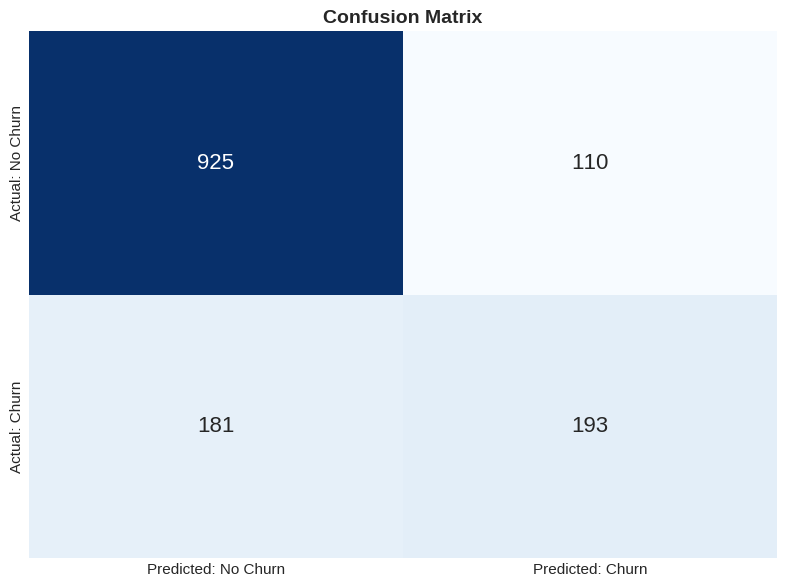


📊 Breakdown:
✅ True Negatives  (correctly predicted 'No Churn'):  925
🚨 False Positives (predicted 'Churn' but didn't):   110
🚨 False Negatives (missed actual churners):          181  ← These cost the business!
✅ True Positives  (correctly predicted 'Churn'):     193


In [32]:
# CELL 32: Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Churn', 'Predicted: Churn'],
            yticklabels=['Actual: No Churn', 'Actual: Churn'],
            cbar=False, annot_kws={'size': 16})
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Explain what each cell means
tn, fp, fn, tp = cm.ravel()
print(f"\n📊 Breakdown:")
print(f"✅ True Negatives  (correctly predicted 'No Churn'):  {tn}")
print(f"🚨 False Positives (predicted 'Churn' but didn't):   {fp}")
print(f"🚨 False Negatives (missed actual churners):          {fn}  ← These cost the business!")
print(f"✅ True Positives  (correctly predicted 'Churn'):     {tp}")

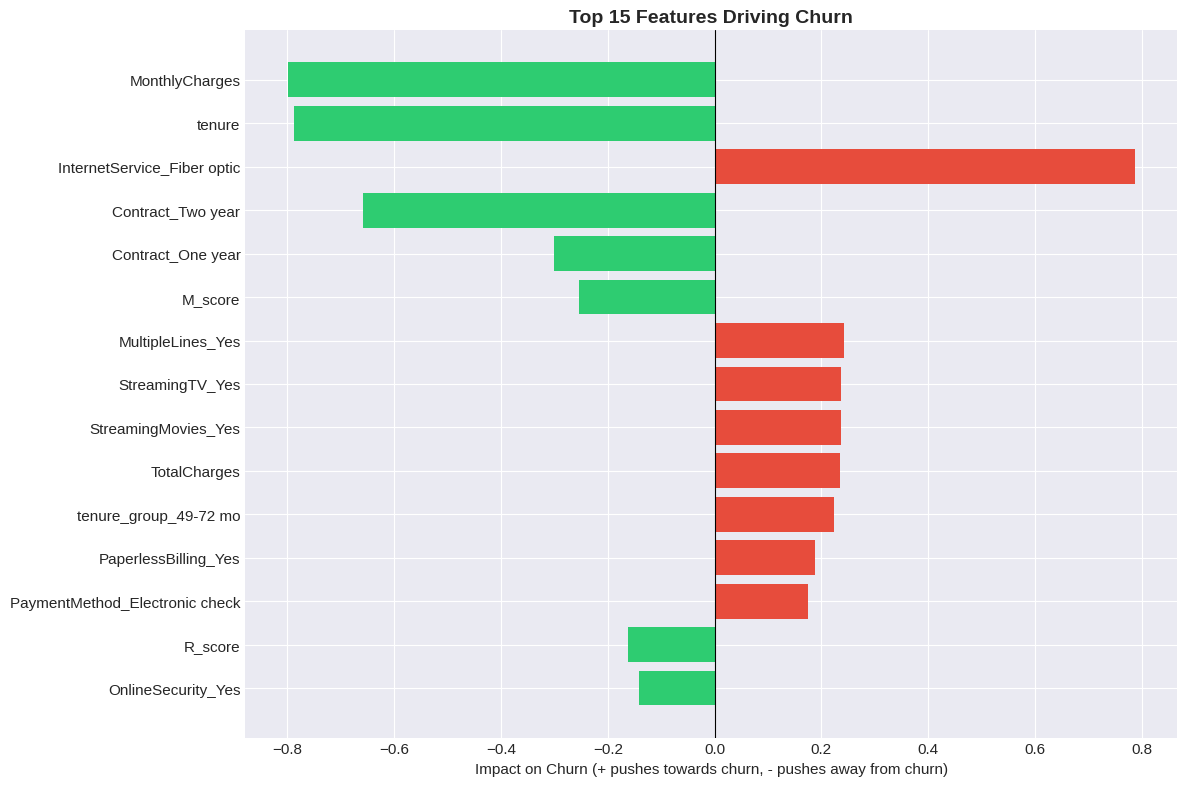


📊 TOP CHURN DRIVERS:
                    Feature  Coefficient
             MonthlyCharges    -0.799543
                     tenure    -0.786932
InternetService_Fiber optic     0.786658
          Contract_Two year    -0.659203
          Contract_One year    -0.300063
                    M_score    -0.253654
          MultipleLines_Yes     0.242267
            StreamingTV_Yes     0.237331
        StreamingMovies_Yes     0.236413
               TotalCharges     0.234280


In [33]:
# CELL 33: Feature Importance — What Drives Churn?

# Get the coefficients (importance) for each feature
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value (most impactful, positive or negative)
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in feature_importance['Coefficient']]
ax.barh(feature_importance['Feature'][::-1], feature_importance['Coefficient'][::-1], color=colors[::-1])
ax.set_title('Top 15 Features Driving Churn', fontsize=14, fontweight='bold')
ax.set_xlabel('Impact on Churn (+ pushes towards churn, - pushes away from churn)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\n📊 TOP CHURN DRIVERS:")
print(feature_importance[['Feature', 'Coefficient']].head(10).to_string(index=False))

In [34]:
# CELL 34: Save Model Outputs

# Create a dataframe with original customer info + predictions
test_results = pd.DataFrame({
    'customerID': df.loc[y_test.index, 'customerID'].values,
    'Actual_Churn': y_test.values,
    'Predicted_Churn': y_pred,
    'Churn_Probability': y_pred_proba.round(3),
    'Risk_Category': pd.cut(y_pred_proba, bins=[0, 0.3, 0.6, 1.0],
                             labels=['Low Risk', 'Medium Risk', 'High Risk'])
})

test_results.to_csv('churn_predictions.csv', index=False)
print("✅ Saved 'churn_predictions.csv' — customer-level risk scores!")

# Top 20 highest-risk customers
print("\n🚨 TOP 20 HIGHEST-RISK CUSTOMERS (Sorted by churn probability):")
top_risk = test_results.sort_values('Churn_Probability', ascending=False).head(20)
print(top_risk.to_string(index=False))

✅ Saved 'churn_predictions.csv' — customer-level risk scores!

🚨 TOP 20 HIGHEST-RISK CUSTOMERS (Sorted by churn probability):
customerID  Actual_Churn  Predicted_Churn  Churn_Probability Risk_Category
5178-LMXOP             1                1              0.893     High Risk
1400-MMYXY             1                1              0.881     High Risk
0295-PPHDO             1                1              0.873     High Risk
6023-YEBUP             1                1              0.873     High Risk
6630-UJZMY             0                1              0.865     High Risk
2545-EBUPK             0                1              0.864     High Risk
6861-XWTWQ             1                1              0.863     High Risk
1069-XAIEM             1                1              0.863     High Risk
9057-SIHCH             1                1              0.862     High Risk
4750-ZRXIU             1                1              0.857     High Risk
8884-ADFVN             1                1        